In [280]:
!pip install -q mlxtend


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



# ⚽ Reglas de asociación en partidos de fútbol

Este notebook simula el análisis de eventos en partidos de fútbol usando el algoritmo Apriori para descubrir patrones frecuentes, como penaltis a favor. Se incluyen partidos de Real Madrid, FC Barcelona, Atlético de Madrid y Villarreal.


### 1. Imports

In [281]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import networkx as nx

### 2. Datos simulados de partidos

In [282]:
# Lista de transacciones (eventos por partido)
datos = [
    ["real madrid", "ataque por banda", "caída en el área", "VAR revisa", "penalti"],
    ["real madrid", "centro al área", "mano del defensa", "penalti"],
    ["real madrid", "contraataque rápido", "caída en el área", "penalti"],
    ["fc barcelona", "ataque por banda", "VAR revisa", "sin penalti"],
    ["fc barcelona", "centro al área", "mano del defensa", "penalti"],
    ["atlético de madrid", "caída en el área", "árbitro no revisa", "sin penalti"],
    ["atlético de madrid", "ataque por banda", "caída en el área", "penalti"],
    ["villarreal", "centro al área", "VAR revisa", "penalti"],
    ["villarreal", "ataque por banda", "caída en el área", "sin penalti"],
    ["villarreal", "mano del defensa", "VAR revisa", "penalti"]
]

# Convertir a DataFrame
df = pd.DataFrame(datos, columns=["equipo", "evento1", "evento2", "evento3", "resultado"])

df

,equipo,evento1,evento2,evento3,resultado
0,real madrid,ataque por banda,caída en el área,VAR revisa,penalti
1,real madrid,centro al área,mano del defensa,penalti,None
2,real madrid,contraataque rápido,caída en el área,penalti,None
3,fc barcelona,ataque por banda,VAR revisa,sin penalti,None
4,fc barcelona,centro al área,mano del defensa,penalti,None
5,atlético de madrid,caída en el área,árbitro no revisa,sin penalti,None
6,atlético de madrid,ataque por banda,caída en el área,penalti,None
7,villarreal,centro al área,VAR revisa,penalti,None
8,villarreal,ataque por banda,caída en el área,sin penalti,None
9,villarreal,mano del defensa,VAR revisa,penalti,None


### 3. Preparación de datos para Apriori

Antes de aplicar el algoritmo Apriori, necesitamos preparar los datos en el formato adecuado. Apriori trabaja con transacciones binarias, donde cada columna representa un posible evento (ítem) y cada fila indica si ese evento ocurrió o no en una transacción determinada (True/False).

TransactionEncoder transformarema nuestra lista de partidos en una tabla binaria de forma que el modelo pueda identificar qué eventos aparecen juntos con mayor frecuencia.

In [283]:
# Eliminar columna de equipo para análisis general
transacciones = datos

# Codificar transacciones
te = TransactionEncoder()
te_ary = te.fit(transacciones).transform(transacciones)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

In [284]:
# Matriz binária que muestra las transaciones
df_trans

,VAR revisa,ataque por banda,atlético de madrid,caída en el área,centro al área,contraataque rápido,fc barcelona,mano del defensa,penalti,real madrid,sin penalti,villarreal,árbitro no revisa
0,True,True,False,True,False,False,False,False,True,True,False,False,False
1,False,False,False,False,True,False,False,True,True,True,False,False,False
2,False,False,False,True,False,True,False,False,True,True,False,False,False
3,True,True,False,False,False,False,True,False,False,False,True,False,False
4,False,False,False,False,True,False,True,True,True,False,False,False,False
5,False,False,True,True,False,False,False,False,False,False,True,False,True
6,False,True,True,True,False,False,False,False,True,False,False,False,False
7,True,False,False,False,True,False,False,False,True,False,False,True,False
8,False,True,False,True,False,False,False,False,False,False,True,True,False
9,True,False,False,False,False,False,False,True,True,False,False,True,False


### 4. Aplicar Apriori


Una vez tenemos las transacciones codificadas (con TransactionEncoder), aplicamos el algoritmo Apriori para descubrir conjuntos de eventos frecuentes (itemsets). <br>
**Apriori** identifica qué combinaciones de sucesos ocurren con una frecuencia superior a un umbral mínimo (min_support).

In [285]:
# Obtener itemsets frecuentes
frequent_itemsets = apriori(df_trans, 
                            min_support=0.3, # Solo consideramos las combinaciones que aparecen como mínimo 30% de las veces 
                            use_colnames=True) # Mostramos los nombres de las columnas en vez de labels

frequent_itemsets

,support,itemsets
0,0.4,(VAR revisa)
1,0.4,(ataque por banda)
2,0.5,(caída en el área)
3,0.3,(centro al área)
4,0.3,(mano del defensa)
5,0.7,(penalti)
6,0.3,(real madrid)
7,0.3,(sin penalti)
8,0.3,(villarreal)
9,0.3,"(VAR revisa, penalti)"


A partir de estos conjuntos frecuentes, generamos reglas de asociación que expresan relaciones del tipo:

    “Si ocurre A y B, entonces probablemente ocurra C.”


In [286]:
# Generar reglas de asociación
reglas = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

reglas

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(VAR revisa),(penalti),0.4,0.7,0.3,0.75,1.071429,1.0,0.02,1.20,0.111111,0.375000,0.166667,0.589286
1,(caída en el área),(ataque por banda),0.5,0.4,0.3,0.60,1.500000,1.0,0.10,1.50,0.666667,0.500000,0.333333,0.675000
2,(ataque por banda),(caída en el área),0.4,0.5,0.3,0.75,1.500000,1.0,0.10,2.00,0.555556,0.500000,0.500000,0.675000
3,(caída en el área),(penalti),0.5,0.7,0.3,0.60,0.857143,1.0,-0.05,0.75,-0.250000,0.333333,-0.333333,0.514286
4,(centro al área),(penalti),0.3,0.7,0.3,1.00,1.428571,1.0,0.09,inf,0.428571,0.428571,1.000000,0.714286
5,(mano del defensa),(penalti),0.3,0.7,0.3,1.00,1.428571,1.0,0.09,inf,0.428571,0.428571,1.000000,0.714286
6,(real madrid),(penalti),0.3,0.7,0.3,1.00,1.428571,1.0,0.09,inf,0.428571,0.428571,1.000000,0.714286


<br><br>

#### Explicación de las columnas

- ``antecedents`` (X): conjunto de sucesos que actúan como condición o causa potencial.
- ``consequents`` (Y): suceso o conjunto de sucesos que representan la consecuencia más probable del antecedente.
- ``support``: frecuencia relativa con la que aparecen juntos el antecedente y el consecuente en el total de transacciones.
    - $Support = \frac{frq(X,Y)}{N}$

- ``confidence``: probabilidad de que se dé el consecuente dado que ha ocurrido el antecedente.
    - $Confidence = \frac{frq(X,Y)}{frq(X)}$

- ``lift``: grado de relación estadística entre antecedente y consecuente:
    - $Lift=\frac{Support}{Supp(X)*Supp(Y)}$

    - lift > 1 : relación positiva (el antecedente aumenta la probabilidad del consecuente)
    - lift = 1 : son independientes
    - lift < 1 : relación negativa (el antecedente reduce la probabilidad del consecuente)

<br>

In [287]:
reglas[["antecedents", "consequents", "support", "confidence", "lift"]]

,antecedents,consequents,support,confidence,lift
0,(VAR revisa),(penalti),0.3,0.75,1.071429
1,(caída en el área),(ataque por banda),0.3,0.60,1.500000
2,(ataque por banda),(caída en el área),0.3,0.75,1.500000
3,(caída en el área),(penalti),0.3,0.60,0.857143
4,(centro al área),(penalti),0.3,1.00,1.428571
5,(mano del defensa),(penalti),0.3,1.00,1.428571
6,(real madrid),(penalti),0.3,1.00,1.428571


### 5. Entrada del usuario

In [288]:
entrada_usuario = input("Introduce eventos del partido separados por comas: ").lower()
entrada = [e.strip() for e in entrada_usuario.split(",")]

entrada

['real madrid', 'falta fuera del area']

### 6. Evaluación de reglas aplicables

En esta parte, el programa revisa todas las **reglas generadas** y comprueba si los antecedentes de alguna de ellas se cumplen dentro de la entrada del usuario.
Si una regla es aplicable (es decir, si todos sus antecedentes aparecen en la entrada), el sistema muestra su **consecuente probable**, junto con la confianza y el lift. <br>
Así podemos evaluar de manera práctica qué **conclusiones pueden inferirse** en un contexto real a partir de los datos históricos.

In [289]:
# Lista que guardará los resultados de las reglas
resultados = []

# Recorremos todas las reglas
for _, regla in reglas.iterrows(): 
    # Miramos si la regla es igual al antecedente
    if regla['antecedents'].issubset(set(entrada)):
        # Guardamos el resultado de la regla aplicada 
        resultados.append({ 
            "antecedents": list(regla['antecedents']),
            "consequents": list(regla['consequents']),
            "confidence": regla['confidence'],
            "lift": regla['lift']
        })

# Mostrar resultados
if resultados:
    for r in resultados:
        print(f"Posible resultado ({r['antecedents']}): {r['consequents']} (confianza: {r['confidence']:.2f}, lift: {r['lift']:.2f})")
else:
    print("No se encontraron reglas aplicables.")


Posible resultado (['real madrid']): ['penalti'] (confianza: 1.00, lift: 1.43)


![Celebración de gol](https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExd2t2YjN6ZjkzZDAxZmt2c3hnbHhtem5tZGtjYWliNnhhNWdmM2NybSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/QzgniJhHKv8p7XvRcd/giphy.gif)

### 7. Visualización de reglas

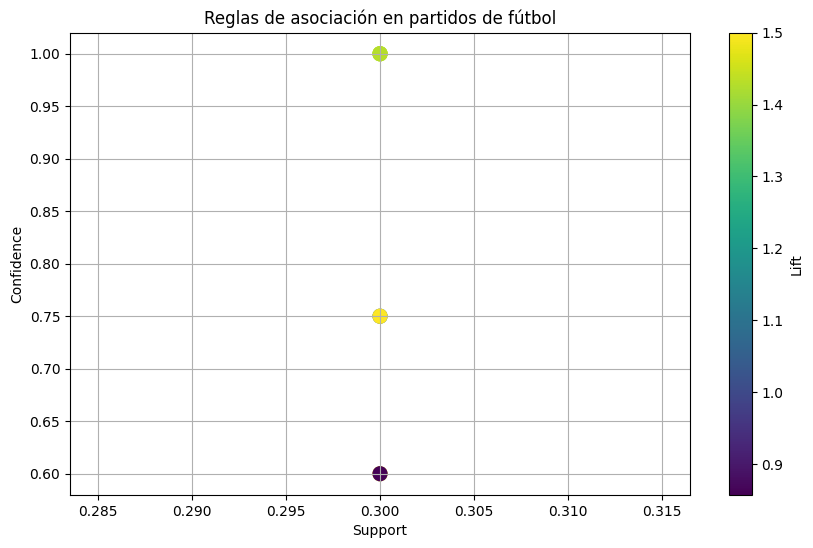

In [290]:
plt.figure(figsize=(10,6))
plt.scatter(reglas['support'], reglas['confidence'], c=reglas['lift'], cmap='viridis', s=100)
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Reglas de asociación en partidos de fútbol')
plt.grid(True)
plt.show()


### 8. Visualización en red de reglas con alto lift

In [291]:
threshold = 1.2

G = nx.DiGraph()

# Recorremos todas las instancias de la tabla de reglas
for _, row in reglas.iterrows():
    # Miramos si el grado de relación estadística entre antecedente y consecuente es superior a 1.2
    if row['lift'] > threshold:
        # Recorremos la lista de antecedentes
        for a in row['antecedents']:
            # Recorremos la lista de consecuencias
            for c in row['consequents']:
                # Creamos un nodo entre antecedente y consecuencia relacionándolos por el grado de relación
                G.add_edge(a, c, weight=row['lift'])

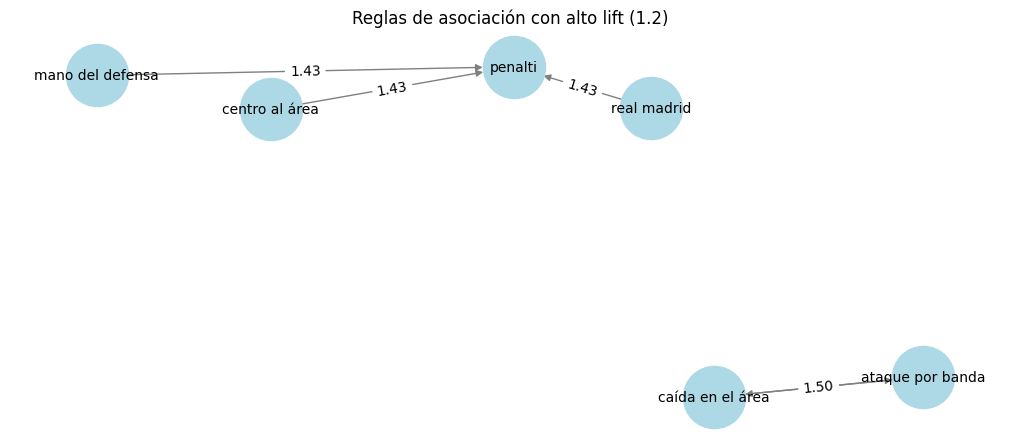

In [292]:
# Mostramos grafo
plt.figure(figsize=(10, 4))

# Calculamos las posiciones de los nodos
pos = nx.spring_layout(G, seed=90)
# Dibujamos nodos
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, edge_color='gray')
labels = nx.get_edge_attributes(G, 'weight')
# Dibjuamos los valores de los lift
nx.draw_networkx_edge_labels(G, pos, edge_labels={k: f"{v:.2f}" for k, v in labels.items()})

plt.title(f"Reglas de asociación con alto lift ({threshold})")
plt.show()

---

# Teoria

La diferencia entre Apriori y FP-Growth radica principalmente en cómo generan las reglas de asociación y cómo manejan la eficiencia computacional. Aquí te explico las diferencias clave:

## 1. Apriori

**Método:**

- Genera conjuntos frecuentes de ítems usando una estrategia de fuerza bruta.<br> 
- Utiliza la propiedad de que si un conjunto es frecuente, todos sus subconjuntos también lo son.<br>
- Requiere múltiples pasadas por la base de datos.<br>

**Ventajas:**

- Fácil de entender e implementar.<br>
- Bueno para conjuntos de datos pequeños.<br>

**Desventajas:**

- Lento en bases de datos grandes.<br>
- Genera muchos candidatos, lo que consume memoria y tiempo.<br>


## 2. FP-Growth (Frequent Pattern Growth)

**Método:**

- Construye una estructura llamada árbol FP (Frequent Pattern Tree).<br>
- Evita la generación de candidatos explícitos.<br>
- Solo necesita dos pasadas por la base de datos.<br>

**Ventajas:**

- Mucho más rápido que Apriori en bases de datos grandes.<br>
- Menor consumo de memoria.<br>
- Escala mejor con grandes volúmenes de datos.<br>

**Desventajas:**

- Más complejo de implementar.

## Resumen:

| Característica | Apriori  | FP-Growth  |
|----------|----------|----------|
| Estrategia  | Generación de candidatos   | Árbol de patrones   |
| Eficiencia  | Baja en grandes datos   | Alta   |
| Pasadas por la BD  | Múltiples   |Solo dos  |
|Facilidad de uso | Fácil | Más complejo|
|Uso de memoria | Alto | Bajo|

<br><br>

---

# Ejercicios de reglas de asociación

1. Supermercado <br>
**Regla:** <br>
Si un cliente compra pan y mantequilla, entonces probablemente también comprará mermelada. <br><br>
**Formato:** <br>
`{pan, mantequilla} → mermelada`
<br><br>

2. Diagnóstico médico <br>
**Regla:** <br>
Si un paciente tiene fiebre y dolor de garganta, entonces probablemente tiene faringitis. <br><br>
**Formato:** <br>
`{fiebre, dolor de garganta} → faringitis`
<br><br>

3. Comportamiento en una app <br>
**Regla:** <br>
Si un usuario visita la sección ofertas y luego carrito, es probable que realice una compra. <br><br>
**Formato:** <br>
`{visita ofertas, visita carrito} → compra`
<br><br>

4. Educación <br>
**Regla:** <br>
Si un estudiante participa en foros y entrega tareas a tiempo, es probable que apruebe el curso. <br><br>
**Formato:** <br>
`{participación en foros, tareas a tiempo} → aprobado`
<br><br>

5. Mantenimiento de maquinaria <br>
**Regla:** <br>
Si una máquina muestra vibración excesiva y temperatura elevada, es probable que tenga fallo en el motor. <br><br>
**Formato:** <br>
`{vibración excesiva, temperatura elevada} → fallo en el motor`
<br><br>